# Imports

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))
from MC2PCA import MC2PCA
from metrics import ClusteringMetrics
from dataset_manager import DatasetManager

import numpy as np
from sklearn.preprocessing import LabelEncoder



# Loading data

In [2]:
ds = DatasetManager("basicmotions")
X_train, y_train = ds.X, ds.y

# Training of the model 

In [3]:
le = LabelEncoder()
y_true_int = le.fit_transform(y_train)


metrics = ClusteringMetrics()

for p in [1,2,3,4,5]:
    model = MC2PCA(p=p, tol=1e-7, max_iter=100)
    model.fit(X_train, K=4)

    metrics.add_run(
        y_true=y_true_int,
        y_pred=model.assignments,
        p=p,
        X=X_train,
        errors=model.errors
    )


# Evaluation

p=1 | ARI=0.277 | NMI=0.487 | Precision=0.575 | Recall=0.775
p=2 | ARI=0.201 | NMI=0.289 | Precision=0.500 | Recall=0.650
p=3 | ARI=0.182 | NMI=0.328 | Precision=0.512 | Recall=0.575
p=4 | ARI=0.155 | NMI=0.233 | Precision=0.500 | Recall=0.650
p=5 | ARI=0.201 | NMI=0.296 | Precision=0.500 | Recall=0.738


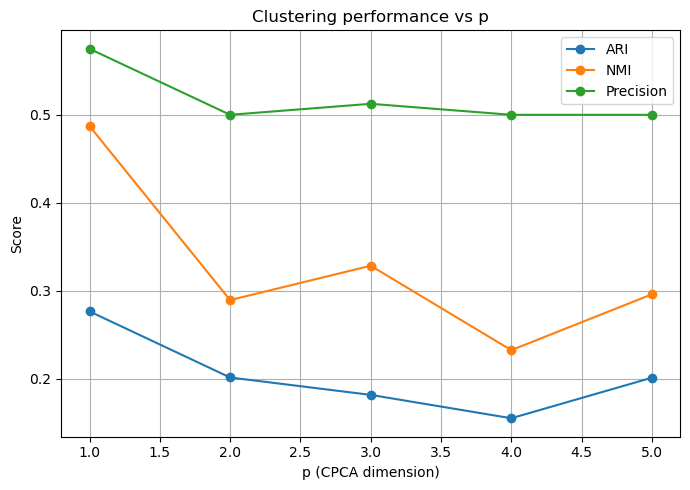

/Users/ilan/anaconda3/envs/kaggle/lib/python3.9/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/Users/ilan/anaconda3/envs/kaggle/lib/python3.9/site-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


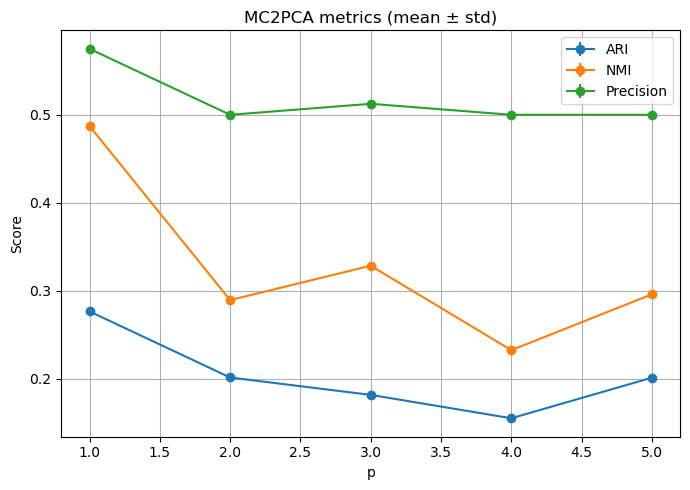

In [4]:
metrics.summary()
metrics.plot_metrics_vs_p()
metrics.plot_metrics_mean_std()

# Robustness of initialisation

In [5]:
le = LabelEncoder()
y_true_int = le.fit_transform(y_train)

metrics = ClusteringMetrics()

p = 3
K = 4
n_runs = 10

for run in range(n_runs):
    perm = np.random.permutation(len(X_train))
    X_perm = [X_train[i] for i in perm]
    y_perm = y_true_int[perm]

    model = MC2PCA(p=p, tol=1e-7, max_iter=100)
    model.fit(X_perm, K=K)

    metrics.add_run(
        y_true=y_perm,
        y_pred=model.assignments,
        p=p,
        X=X_perm,
        errors=model.errors
    )


In [6]:
metrics.summary()


p=3 | ARI=0.218 | NMI=0.338 | Precision=0.512 | Recall=0.625
p=3 | ARI=0.261 | NMI=0.336 | Precision=0.550 | Recall=0.575
p=3 | ARI=0.182 | NMI=0.328 | Precision=0.512 | Recall=0.575
p=3 | ARI=0.182 | NMI=0.328 | Precision=0.512 | Recall=0.575
p=3 | ARI=0.264 | NMI=0.359 | Precision=0.550 | Recall=0.625
p=3 | ARI=0.205 | NMI=0.333 | Precision=0.512 | Recall=0.613
p=3 | ARI=0.249 | NMI=0.322 | Precision=0.537 | Recall=0.525
p=3 | ARI=0.228 | NMI=0.404 | Precision=0.500 | Recall=0.787
p=3 | ARI=0.187 | NMI=0.329 | Precision=0.512 | Recall=0.588
p=3 | ARI=0.241 | NMI=0.350 | Precision=0.512 | Recall=0.650


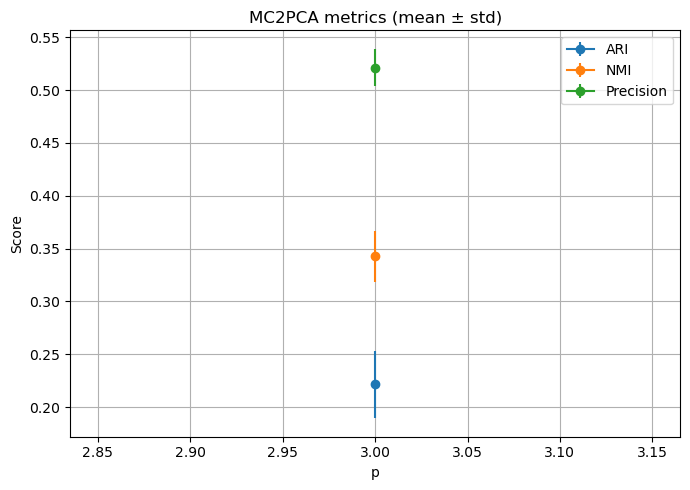

In [7]:
metrics.plot_metrics_mean_std()

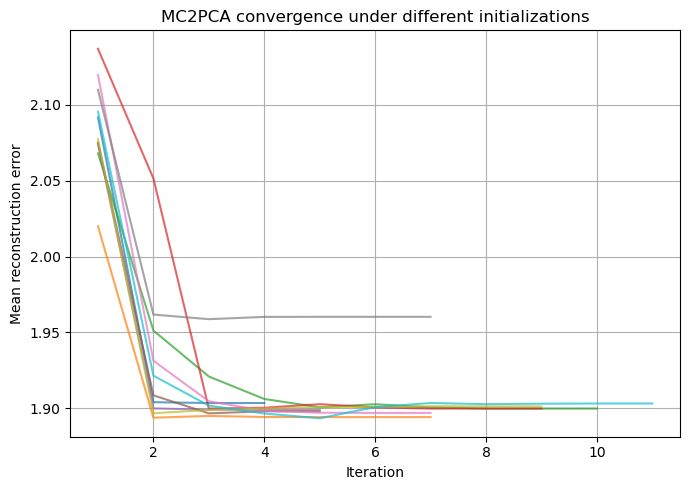

In [8]:
metrics.plot_convergence_all_runs(p=3)

/Users/ilan/anaconda3/envs/kaggle/lib/python3.9/site-packages/numpy/core/_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


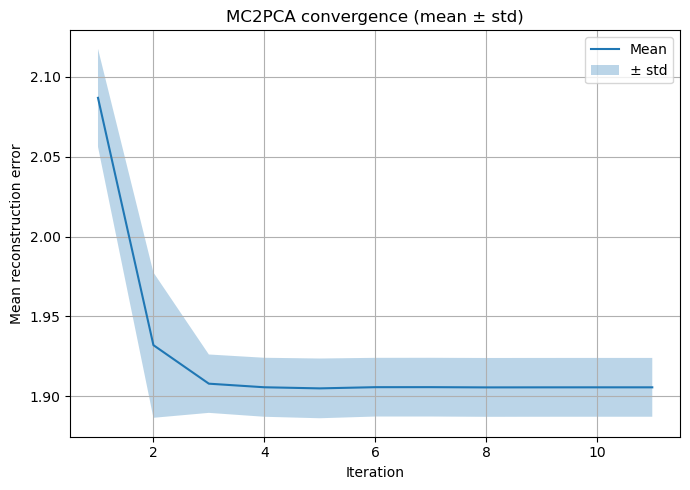

In [9]:
metrics.plot_convergence_mean_std(p=3)

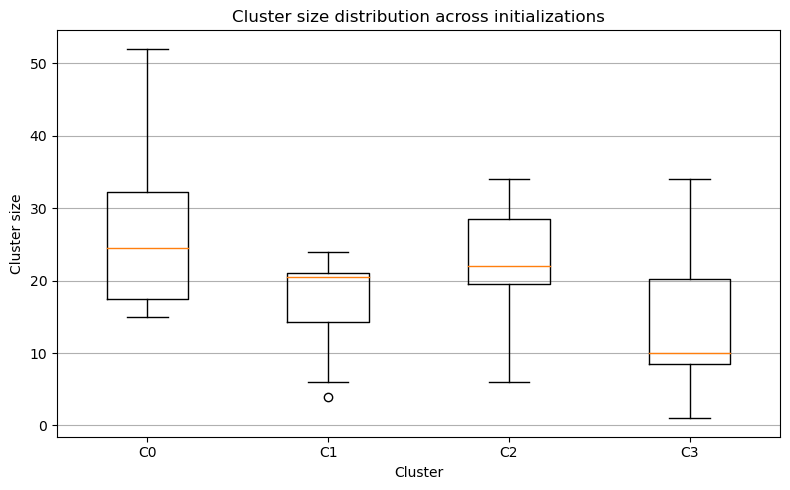

In [10]:
metrics.plot_cluster_size_boxplot(p=3)